# Isolation Forest for Sales Drop Detection

## Overview

This notebook presents an unsupervised anomaly detection approach as part of a broader comparative study (TCN, LightGBM, Isolation Forest) for identifying anomalous hourly sales drops. All models operate on the identical subset of products and data for fair benchmarking.

**Key characteristics of Isolation Forest in this task:**
- Does not require a target variable, making it suitable for cold-start products and previously unseen anomaly patterns.
- Fast training on 32 engineered features (13 product-level historical profiles + temporal and rolling statistics).
- Contamination parameter set to 0.13% — an estimate based on the expected proportion of anomalies (65 labeled events across ~360k August observations).

**Feature engineering is grounded in EDA:**
- Product profile features (`hist_cv`, `hist_adi`, `hist_peak`, etc.) directly reflect the high intermittency and bursty sales behavior (mean ADI ≈ 245, 96.83% zero sales).
- Temporal and rolling features (lags and windows of 6/24/168 hours) capture the daily and weekly patterns discovered during exploratory data analysis.

**Anomaly Detection Logic:**
- Threshold: anomaly score below the 0.13th percentile + mandatory business filter (stocks > 0 and operating hours 7–22).
- The model is trained once on data up to July 31 and scored on August data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from sklearn.ensemble import IsolationForest

In [2]:
DATA_PATH             = r'C:\Users\User\Desktop\диплом\data_v1.csv'
AUG_AN_PATH           = r'C:\Users\User\Desktop\диплом\df_aug_final.csv'
AUG_ZERO_PATH         = r'C:\Users\User\Desktop\диплом\df_aug_final_check_rows.csv'
ANOMALIES_OUTPUT_PATH = r'C:\Users\User\Desktop\диплом\isolation_forest_final_an.csv'

In [3]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
print("Initial size:", df.shape)

df = df[df['date'] <= '2025-08-31'].copy()

# Remove cold products (first sale in August or later)
first_pos = df[df['sales'] > 0].groupby('product')['date'].min()
aug_start = pd.Timestamp('2025-08-01')
cold = first_pos[first_pos >= aug_start].index.tolist()
df = df[~df['product'].isin(cold)].copy()
print(f"After removing cold products: {df.shape}")

# Top-500 products by August sales volume
aug_df = df[df['date'] >= aug_start].copy()
prod_sales = aug_df.groupby('product')['sales'].sum().reset_index()
top_500 = prod_sales.nlargest(500, 'sales')['product'].tolist()

# Products with known labeled anomalies
df_aug_zero = pd.read_csv(AUG_ZERO_PATH)
anomaly_products = df_aug_zero['product'].unique().tolist()

selected_products = list(set(top_500 + anomaly_products))
print(f"Top-500 (August only): {len(top_500)} | Anomaly products: {len(anomaly_products)} | Total: {len(selected_products)}")

df = df[df['product'].isin(selected_products)].copy()
print(f"After filtering: {df.shape}")

del first_pos, cold, prod_sales, aug_df
gc.collect()

Initial size: (64081080, 6)
After removing cold products: (41779767, 6)
Top-500 (August only): 500 | Anomaly products: 13 | Total: 500
After filtering: (2736500, 6)


20

## Feature Engineering

Two layers of features are built:

1. **Product profile** — 13 static historical metrics computed over each product's full pre-August history (mean, std, CV, zero rate, ADI, peak ratio, etc.). These capture stable product-level behavior.
2. **Temporal and dynamic features** — hour, day of week, lag sales (1h / 24h / 168h), rolling mean and std (6h / 24h / 168h), z-score, pct change, and sales-vs-mean ratio. These capture within-day and within-week patterns.

In [4]:
df = df.sort_values(['product', 'date']).reset_index(drop=True)

# Split: training data goes up to July 31
df_til_sep = df[df['date'] <= '2025-07-31'].copy()
print(f"df_til_sep (train): {df_til_sep.shape}")

df_til_sep (train): (2376000, 6)


In [5]:
products = df_til_sep[['product', 'category']].drop_duplicates().reset_index(drop=True)

first_sales = (df_til_sep[df_til_sep['sales'] > 0]
               .groupby('product')['date'].min()
               .reset_index())
first_sales.columns = ['product', 'first_sale_date']
products = products.merge(first_sales, on='product', how='left')

df_active = df_til_sep.merge(first_sales[['product', 'first_sale_date']], on='product', how='left')
df_active = df_active[df_active['date'] >= df_active['first_sale_date']]

all_features = df_active.groupby('product').agg(
    hist_mean     = ('sales', 'mean'),
    hist_std      = ('sales', 'std'),
    hist_cv       = ('sales', lambda x: x.std() / (x.mean() + 1e-6)),
    hist_zero     = ('sales', lambda x: (x == 0).mean()),
    hist_adi      = ('sales', lambda x: (x == 0).sum() / max((x > 0).sum(), 1)),
    hist_max      = ('sales', 'max'),
    hist_p99      = ('sales', lambda x: np.percentile(x, 99)),
    hist_peak     = ('sales', lambda x: x.max() / (x.mean() + 1e-6)),
    hist_outlier  = ('sales', lambda x: (x > np.percentile(x, 99)).mean()),
    hist_pos_rate = ('sales', lambda x: (x > 0).mean()),
    accel         = ('sales', lambda x: x.iloc[-72:].mean() / (x.iloc[:72].mean() + 1e-6) if len(x) >= 144 else 1.0),
    recent_vs_avg = ('sales', lambda x: x.iloc[-72:].mean() / (x.mean() + 1e-6)),
    vol_3d        = ('sales', lambda x: x.iloc[-72:].std() / (x.iloc[-72:].mean() + 1e-6) if len(x) >= 72 else 0.0),
).reset_index()

del df_active, first_sales
gc.collect()

products = products.merge(all_features, on='product', how='left')
del all_features
gc.collect()

feature_cols = ['hist_mean', 'hist_std', 'hist_cv', 'hist_zero', 'hist_adi',
                'hist_max', 'hist_p99', 'hist_peak', 'hist_outlier', 'hist_pos_rate',
                'accel', 'recent_vs_avg', 'vol_3d']

for col in feature_cols:
    cat_median = products.groupby('category')[col].median()
    products.loc[products[col].isna(), col] = products.loc[products[col].isna(), 'category'].map(cat_median)

products[feature_cols] = products[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).astype('float32')

print(f"Product profile: {len(products)} products, {len(feature_cols)} historical features")

Product profile: 500 products, 13 historical features


In [6]:
df_til_sep = df_til_sep.sort_values(['product', 'date']).reset_index(drop=True)

df_til_sep['hour']       = df_til_sep['date'].dt.hour.astype('int8')
df_til_sep['dayofweek']  = df_til_sep['date'].dt.dayofweek.astype('int8')
df_til_sep['is_weekend'] = (df_til_sep['dayofweek'] >= 5).astype('int8')
df_til_sep['week']       = df_til_sep['date'].dt.isocalendar().week.astype('uint8')

df_til_sep['sales_lag_1h']   = df_til_sep.groupby('product')['sales'].shift(1)
df_til_sep['sales_lag_24h']  = df_til_sep.groupby('product')['sales'].shift(24)
df_til_sep['sales_lag_168h'] = df_til_sep.groupby('product')['sales'].shift(168)
gc.collect()

for window in [6, 24, 168]:
    min_p = max(1, window // 2)
    df_til_sep[f'rolling_mean_{window}h'] = (
        df_til_sep.groupby('product')['sales']
        .transform(lambda x: x.rolling(window, min_periods=min_p).mean())
        .astype('float32')
    )
    df_til_sep[f'rolling_std_{window}h'] = (
        df_til_sep.groupby('product')['sales']
        .transform(lambda x: x.rolling(window, min_periods=min_p).std())
        .astype('float32')
    )
    gc.collect()

df_til_sep['z_score_24h'] = (
    (df_til_sep['sales'] - df_til_sep['rolling_mean_24h']) /
    (df_til_sep['rolling_std_24h'] + 1e-6)
).astype('float32')

df_til_sep['pct_change_1h']  = df_til_sep.groupby('product')['sales'].pct_change(1).astype('float32')
df_til_sep['pct_change_24h'] = df_til_sep.groupby('product')['sales'].pct_change(24).astype('float32')

df_til_sep['sales_vs_mean_24h'] = (
    df_til_sep['sales'] / (df_til_sep['rolling_mean_24h'] + 1e-6)
).astype('float32')

numeric_cols = df_til_sep.select_dtypes(include=[np.number]).columns.tolist()
df_til_sep[numeric_cols] = df_til_sep[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"df_til_sep: {df_til_sep.shape}")
print(f"Total features: {df_til_sep.shape[1]}")

df_til_sep: (2376000, 23)
Total features: 23


In [7]:
df_til_sep = df_til_sep.merge(
    products[['product'] + feature_cols],
    on='product', how='left'
)

del products
gc.collect()

print(f"df_til_sep after profile merge: {df_til_sep.shape}")
print(f"Memory: {df_til_sep.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

df_til_sep after profile merge: (2376000, 36)
Memory: 0.50 GB


In [8]:
df_aug_MA = pd.read_csv(AUG_AN_PATH)
df_aug_MA_zero_rows = pd.read_csv(AUG_ZERO_PATH)

df_aug_MA['date']     = pd.to_datetime(df_aug_MA['date'])
df_aug_MA['product']  = df_aug_MA['product'].astype('string')
df_aug_MA['category'] = df_aug_MA['category'].astype('int32')
df_aug_MA['stocks']   = df_aug_MA['stocks'].astype('float32')
df_aug_MA['sales']    = df_aug_MA['sales'].astype('float32')
df_aug_MA['price']    = df_aug_MA['price'].astype('float32')

df_aug_MA_zero_rows['date']     = pd.to_datetime(df_aug_MA_zero_rows['date'])
df_aug_MA_zero_rows['product']  = df_aug_MA_zero_rows['product'].astype('string')
df_aug_MA_zero_rows['category'] = df_aug_MA_zero_rows['category'].astype('int32')
df_aug_MA_zero_rows['stocks']   = df_aug_MA_zero_rows['stocks'].astype('float32')
df_aug_MA_zero_rows['sales']    = df_aug_MA_zero_rows['sales'].astype('float32')
df_aug_MA_zero_rows['price']    = df_aug_MA_zero_rows['price'].astype('float32')

print(f"df_aug_MA: {df_aug_MA.shape}")
print(f"Ground truth anomalies: {len(df_aug_MA_zero_rows)}")

df_aug_MA: (5287704, 7)
Ground truth anomalies: 65


In [9]:
key_cols    = ['product', 'date']
cols_to_add = [col for col in df_til_sep.columns
               if col not in ['product', 'date', 'category', 'stocks', 'sales', 'price']]

df_aug_MA = df_aug_MA.merge(
    df_til_sep[key_cols + cols_to_add],
    on=key_cols, how='left'
)

print(f"df_aug_MA after feature join: {df_aug_MA.shape}")
print(f"Nulls after join: {df_aug_MA.isnull().sum().sum()}")

df_test = df_aug_MA
del df_aug_MA
gc.collect()

df_test['date'] = pd.to_datetime(df_test['date'])
df_test['hour'] = df_test['date'].dt.hour

df_aug_MA after feature join: (5287704, 37)
Nulls after join: 158631120


In [10]:
exclude_cols = ['product', 'date', 'category', 'first_sale_date', 'sales',
                'predicted_sales', 'residual', 'residual_zscore',
                'mandatory_filter', 'is_drop_anomaly']

features = [col for col in df_til_sep.columns if col not in exclude_cols]
print(f"Features for model: {len(features)}")
print(features)

Features for model: 32
['stocks', 'price', 'hour', 'dayofweek', 'is_weekend', 'week', 'sales_lag_1h', 'sales_lag_24h', 'sales_lag_168h', 'rolling_mean_6h', 'rolling_std_6h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h', 'rolling_std_168h', 'z_score_24h', 'pct_change_1h', 'pct_change_24h', 'sales_vs_mean_24h', 'hist_mean', 'hist_std', 'hist_cv', 'hist_zero', 'hist_adi', 'hist_max', 'hist_p99', 'hist_peak', 'hist_outlier', 'hist_pos_rate', 'accel', 'recent_vs_avg', 'vol_3d']


In [11]:
df_train = df_til_sep[df_til_sep['date'].dt.month < 8].copy()

del df_til_sep
gc.collect()

print(f"Train (Jan–Jul): {df_train.shape}")
print(f"Test  (August):  {df_test.shape}")

Train (Jan–Jul): (2376000, 36)
Test  (August):  (5287704, 38)


In [12]:
X_train_if = df_train[features]
X_test_if  = df_test[features]

if_model = IsolationForest(
    n_estimators=300,
    max_samples='auto',
    contamination=0.0013,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

if_model.fit(X_train_if)
print("Isolation Forest trained on January–July data")
print(f"  Estimators: {if_model.n_estimators}")
print(f"  Contamination: {if_model.contamination}")

Isolation Forest trained on January–July data
  Estimators: 300
  Contamination: 0.0013


In [13]:
df_test['if_score']   = if_model.decision_function(X_test_if)
df_test['if_anomaly'] = (if_model.predict(X_test_if) == -1)

score_threshold = np.percentile(df_test['if_score'], 0.13)

df_test['if_drop_anomaly'] = (
    (df_test['stocks'] > 0) &
    (df_test['hour'] >= 7) &
    (df_test['hour'] <= 22) &
    (df_test['if_score'] < score_threshold)
)

anomaly_count = df_test['if_drop_anomaly'].sum()
print(f"Drop anomalies detected: {anomaly_count}")
print(f"Score threshold (0.13th pct): {score_threshold:.5f}")

Drop anomalies detected: 1942
Score threshold (0.13th pct): 0.30553


In [14]:
gt          = df_aug_MA_zero_rows[['product', 'date']].copy()
model_anoms = df_test[df_test['if_drop_anomaly']][['product', 'date']].copy()
matches     = model_anoms.merge(gt, on=['product', 'date'], how='inner')

total_model = len(model_anoms)
total_gt    = len(gt)
tp          = len(matches)

recall    = tp / total_gt
precision = tp / total_model if total_model > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"{'Metric':<20} {'Value':>10}")
print("=" * 32)
print(f"{'Detected anomalies':<20} {total_model:>10}")
print(f"{'Ground truth total':<20} {total_gt:>10}")
print(f"{'True positives':<20} {tp:>10}")
print(f"{'Recall':<20} {recall:>10.1%}")
print(f"{'Precision':<20} {precision:>10.1%}")
print(f"{'F1-score':<20} {f1:>10.3f}")
print("=" * 32)

# Missed ground truth
missed = gt.merge(model_anoms, on=['product', 'date'], how='left', indicator=True)
missed = missed[missed['_merge'] == 'left_only'].drop('_merge', axis=1)
print(f"\nMissed ground truth anomalies: {len(missed)}")
print(missed.to_string(index=False))

Metric                    Value
Detected anomalies         1942
Ground truth total           65
True positives                0
Recall                     0.0%
Precision                  0.0%
F1-score                  0.000

Missed ground truth anomalies: 65
        product                date
1784610E0074356 2025-08-02 13:00:00
178462000315388 2025-08-03 09:00:00
17846D000004968 2025-08-03 10:00:00
1784610E0074356 2025-08-03 13:00:00
1784610E0075437 2025-08-04 10:00:00
178461100071922 2025-08-04 10:00:00
1784610E0074356 2025-08-04 11:00:00
1784610E0074356 2025-08-05 08:00:00
1784610E0074356 2025-08-05 11:00:00
1784610E0075437 2025-08-05 14:00:00
 17846ЦТ0036199 2025-08-05 18:00:00
1784610E0074360 2025-08-05 19:00:00
1784610E0074360 2025-08-05 22:00:00
178462000214171 2025-08-06 07:00:00
1784610E0074360 2025-08-06 17:00:00
178462000214171 2025-08-06 18:00:00
1784610E0074360 2025-08-08 21:00:00
1784610E0074360 2025-08-09 20:00:00
 17846ЦТ0037776 2025-08-10 08:00:00
1784610E0074360 2025-

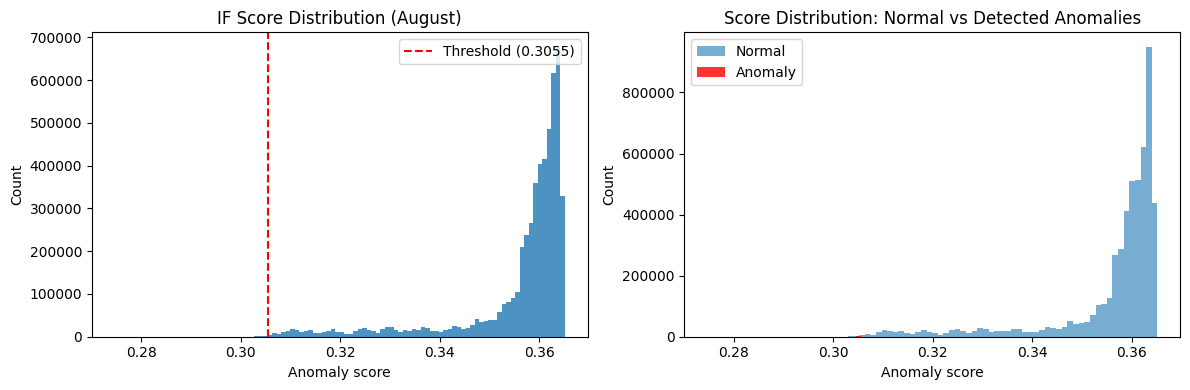

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_test['if_score'], bins=100, edgecolor='none', alpha=0.8)
axes[0].axvline(score_threshold, color='red', linestyle='--', label=f'Threshold ({score_threshold:.4f})')
axes[0].set_xlabel('Anomaly score')
axes[0].set_ylabel('Count')
axes[0].set_title('IF Score Distribution (August)')
axes[0].legend()

anomaly_scores = df_test[df_test['if_drop_anomaly']]['if_score']
normal_scores  = df_test[~df_test['if_drop_anomaly']]['if_score']
axes[1].hist(normal_scores,  bins=80, alpha=0.6, label='Normal',  edgecolor='none')
axes[1].hist(anomaly_scores, bins=30, alpha=0.8, label='Anomaly', edgecolor='none', color='red')
axes[1].set_xlabel('Anomaly score')
axes[1].set_ylabel('Count')
axes[1].set_title('Score Distribution: Normal vs Detected Anomalies')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
anomalies_if = df_test[df_test['if_drop_anomaly']].copy()

output_cols = ['date', 'product', 'category', 'stocks', 'sales', 'price']

anomalies_out = anomalies_if[output_cols].sort_values('date').reset_index(drop=True)

anomalies_out.to_csv(ANOMALIES_OUTPUT_PATH, index=False)

print(f"Saved: {len(anomalies_out)} rows → {ANOMALIES_OUTPUT_PATH}")
print(f"Columns: {list(anomalies_out.columns)}")
print(anomalies_out.head(3).to_string())

Saved: 1942 rows → C:\Users\User\Desktop\диплом\isolation_forest_final_an.csv
Columns: ['date', 'product', 'category', 'stocks', 'sales', 'price']
                 date          product   category  stocks  sales        price
0 2025-08-01 21:00:00  178462000403225  161010701     1.0    0.0  2749.500000
1 2025-08-01 21:00:00  178462000336327  161040305     5.0    0.0  2499.899902
2 2025-08-01 21:00:00  178462000564415  163010504     5.0    0.0  3989.899902
